# Pure premium

The **pure premium** is the expected claim cost of a policy per year: what it should cost the insurer in claims, before expenses, profit and any large-loss loading. There are two standard ways to model it:

1. **Frequency x severity**: multiply the predicted claims per year (notebook 02) by the predicted cost per claim (notebook 03).
2. **Tweedie**: model claim cost per policy-year directly, in one model, with a Tweedie distribution.

Both are fitted as a GLM and as a GBM, giving four models. Everything is on **capped** claim cost (claims capped at EUR 50,000); the large-loss loading is added back at the end. As before, choices are made on the training data and the test set is scored once. All metrics are exposure-weighted.

In [1]:
import gc
import pickle

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from pricing.data import LARGE_LOSS_CAP, PROJECT_ROOT, build_policy_table, load_raw, split_train_test
from pricing.evaluation import balance, calibration_table, gini, lorenz_curve, tweedie_deviance
from pricing.features import BANDS, add_glm_bands, band_labels, base_levels, gbm_matrix, glm_design_matrix, glm_levels
from pricing.gbm import BASE_PARAMS, TweedieGBM, cv_tweedie_gbm
from pricing.glm import fit_tweedie_glm, predict, relativities
from pricing.plots import plot_calibration, plot_lorenz, plot_relativity_comparison, save, set_style

set_style()
pl.Config.set_tbl_rows(40)
pl.Config.set_float_precision(4)
PROCESSED = PROJECT_ROOT / "data" / "processed"

In [2]:
freq_raw, sev_raw = load_raw()
train, test = split_train_test(build_policy_table(freq_raw, sev_raw, large_loss_cap=LARGE_LOSS_CAP))
cost_train, e_train = train["ClaimAmount"].to_numpy(), train["Exposure"].to_numpy()
cost_test, e_test = test["ClaimAmount"].to_numpy(), test["Exposure"].to_numpy()
print(f"Train pure premium (capped): EUR {cost_train.sum() / e_train.sum():.2f} per policy-year")
print(f"Test pure premium (capped):  EUR {cost_test.sum() / e_test.sum():.2f} per policy-year")

Train pure premium (capped): EUR 127.94 per policy-year
Test pure premium (capped):  EUR 135.53 per policy-year


## 1. Frequency x severity

The frequency and severity notebooks saved their test-set predictions. The pure premium per policy-year is their product:

$$\text{pure premium} = \underbrace{\text{claims per year}}_{\text{frequency}} \times \underbrace{\text{cost per claim}}_{\text{severity}}$$

This relies on frequency and severity being independent given the rating factors: knowing how often a policy claims says nothing extra about how much each claim costs.

In [3]:
freq_pred = pl.read_parquet(PROCESSED / "frequency_test_predictions.parquet")
sev_pred = pl.read_parquet(PROCESSED / "severity_test_predictions.parquet")
preds = test.select("IDpol").join(freq_pred, on="IDpol", how="left").join(sev_pred, on="IDpol", how="left")
assert preds.height == test.height and preds["freq_glm"].null_count() == 0 and preds["sev_glm"].null_count() == 0

pred_test = {
    "GLM freq x sev": (preds["freq_glm"] * preds["sev_glm"]).to_numpy(),
    "GBM freq x sev": (preds["freq_gbm"] * preds["sev_gbm"]).to_numpy(),
}

## 2. The Tweedie distribution

Claim cost per policy is an awkward target. Most policies (96%) cost nothing, so there is a large spike at exactly zero; the rest are positive and skewed. Neither a Poisson (counts) nor a Gamma (strictly positive) model fits that shape on its own.

A **Tweedie** distribution with power $p$ between 1 and 2 is exactly this shape. It is a **compound Poisson-Gamma**: a Poisson number of claims, each with a Gamma-distributed cost, added up. Zero claims gives a cost of exactly zero; otherwise the cost is a positive sum. So one Tweedie model describes frequency and severity together.

The power $p$ sets how the variance grows with the mean: $\text{Var} \propto \text{mean}^p$. $p = 1$ is Poisson and $p = 2$ is Gamma, and values in between blend the two. It has to be chosen.

### Choosing the power: theory

If claims are Poisson and each claim's cost is Gamma with shape $\alpha$, the Tweedie power is

$$p = \frac{\alpha + 2}{\alpha + 1}$$

The severity GLM estimated the Gamma dispersion $\phi = 1/\alpha$, so the power implied by our own claims can be read off:

In [4]:
with open(PROCESSED / "severity_glm.pkl", "rb") as fh:
    sev_saved = pickle.load(fh)
alpha = 1 / sev_saved["results"].scale
print(f"Severity dispersion {sev_saved['results'].scale:.2f}, Gamma shape {alpha:.2f}, implied power {(alpha + 2) / (alpha + 1):.2f}")

Severity dispersion 4.47, Gamma shape 0.22, implied power 1.82


A shape below 1 means claim costs are very spread out relative to their mean, which pushes the power towards 2.

### Choosing the power: validation

The power cannot be chosen by comparing each model's own Tweedie deviance, because each power defines a different deviance on a different scale. Instead, the training data is split again (80% to fit, 20% to validate) and a grid of powers is scored on measures that do not depend on the power being tested: the Gini, the balance, and the Tweedie deviance at two fixed reference powers.

The GBMs use 31 leaves with early stopping on the validation part, and are **rebased**, as explained below.

In [5]:
fit_df, val_df = split_train_test(train)
fit_b = add_glm_bands(fit_df)
lv, bs = glm_levels(fit_b), base_levels(fit_b)
X_fit, X_val = glm_design_matrix(fit_b, lv, bs), glm_design_matrix(add_glm_bands(val_df), lv, bs)
G_fit, G_val = gbm_matrix(fit_df), gbm_matrix(val_df)
c_fit, e_fit = fit_df["ClaimAmount"].to_numpy(), fit_df["Exposure"].to_numpy()
c_val, e_val = val_df["ClaimAmount"].to_numpy(), val_df["Exposure"].to_numpy()


def validation_scores(model, power, pred):
    return {"model": model, "power": power, "gini": gini(c_val, pred, e_val), "balance": balance(c_val, pred, e_val),
            "deviance_p1.5": tweedie_deviance(c_val, pred, e_val, 1.5),
            "deviance_p1.8": tweedie_deviance(c_val, pred, e_val, 1.8)}


rows = []
for power in [1.2, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]:
    res = fit_tweedie_glm(X_fit, c_fit, e_fit, power)
    rows.append(validation_scores("GLM", power, predict(res, X_val)))
    del res
    gc.collect()

    d_fit = lgb.Dataset(G_fit, label=c_fit / e_fit, weight=e_fit)
    d_val = lgb.Dataset(G_val, label=c_val / e_val, weight=e_val, reference=d_fit)
    params = {**BASE_PARAMS, "objective": "tweedie", "tweedie_variance_power": power, "metric": "tweedie", "num_leaves": 31}
    booster = lgb.train(params, d_fit, 3000, valid_sets=[d_val], callbacks=[lgb.early_stopping(100, verbose=False)])
    raw_val = booster.predict(G_val)
    rebase = c_fit.sum() / np.sum(booster.predict(G_fit) * e_fit)
    rows.append({**validation_scores("GBM", power, rebase * raw_val), "balance_before_rebase": balance(c_val, raw_val, e_val)})

power_grid = pl.DataFrame(rows, infer_schema_length=None).sort("model", "power")
power_grid

model,power,gini,balance,deviance_p1.5,deviance_p1.8,balance_before_rebase
str,f64,f64,f64,f64,f64,f64
"""GBM""",1.2000,0.3612,0.9943,69.4056,29.2760,0.9240
"""GBM""",1.4000,0.3686,0.9949,69.3466,29.2473,0.9012
"""GBM""",1.5000,0.3626,0.9948,69.5151,29.2775,0.8910
"""GBM""",1.6000,0.3602,0.9947,69.6252,29.3033,0.8827
"""GBM""",1.7000,0.3629,0.9951,69.6012,29.2925,0.8693
"""GBM""",1.8000,0.3584,0.9956,69.8150,29.3376,0.8529
"""GBM""",1.9000,0.3539,0.9951,70.0639,29.3908,0.8411
"""GLM""",1.2000,0.3255,0.9944,70.5686,29.5196,null
"""GLM""",1.4000,0.3281,0.9968,70.5296,29.5074,null


Two things show up.

**The choice of power matters little here.** Across 1.4 to 1.9 the Gini moves in the third decimal place for both models, and the deviance at each reference power barely changes. The data does not pick out a power, so **p = 1.8** is used: the value implied by our own severity data, and inside the range where validation results are flat.

**The GBM needs rebasing.** Before rebasing (last column), the Tweedie GBM predicts only 84 to 92% of the observed cost, and less as the power rises. This is a property of boosting with a Tweedie loss, not of this data. Each tree moves a leaf's log-prediction by one Newton step. For a leaf with no claims that step is about $-1/(2-p)$ before the learning rate, which is $-5$ at $p = 1.8$; for a leaf with large claims it can be at most $+1/(p-1)$, about $+1.25$, however large the claims. Most leaves contain no claims, so each tree pulls the overall level down faster than it can be pushed back up, and early stopping ends training before it recovers. The fix is to multiply every prediction by one factor so that total predicted cost equals total training cost. That leaves the ranking of policies, and so the Gini, unchanged.

In [6]:
POWER = 1.8
del X_fit, X_val
gc.collect()

0

## 3. Tweedie GLM

Fitted on the full training data with the same banded factors as the frequency GLM. Its relativities describe pure premium directly. For comparison, the frequency x severity GLM's pure premium relativities are the frequency relativity times the severity relativity (1 for factors not in the severity model).

In [7]:
train_b = add_glm_bands(train)
levels, base = glm_levels(train_b), base_levels(train_b)
X_train = glm_design_matrix(train_b, levels, base)
tweedie_glm = fit_tweedie_glm(X_train, cost_train, e_train, POWER)
del X_train
gc.collect()
print(f"Converged: {tweedie_glm.mle_retvals['converged']}, training balance: "
      f"{balance(cost_train, predict(tweedie_glm, glm_design_matrix(train_b, levels, base)), e_train):.4f}")

Converged: True, training balance: 1.0149


The training balance is close to 1 but not exactly 1 (about 1.5% over here). A Poisson GLM with a log link reproduces total claims exactly; a Tweedie GLM with a log link does not, because the log link is not its "natural" (canonical) link for powers above 1. The validation grid above shows the gap growing with the power. In practice the model would be rebased, like the GBM; it is left as fitted here so the comparison shows it.

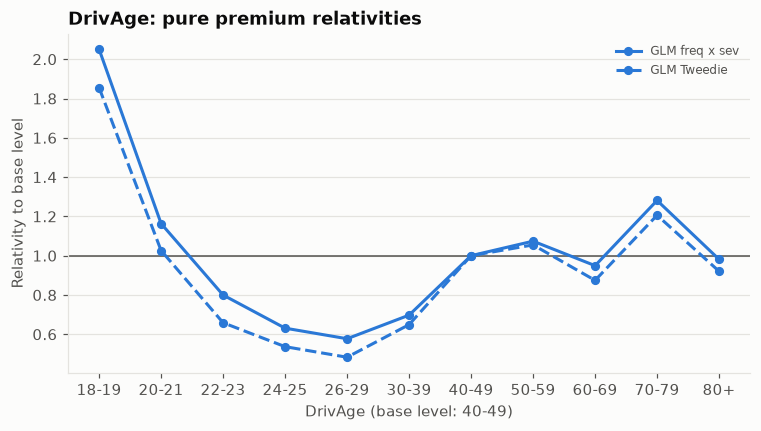

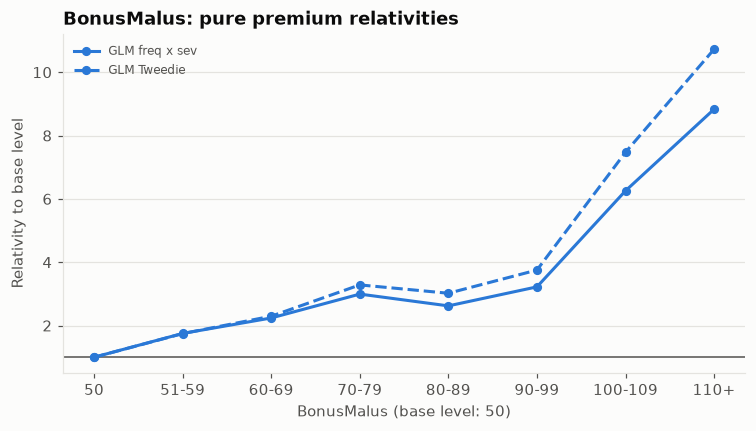

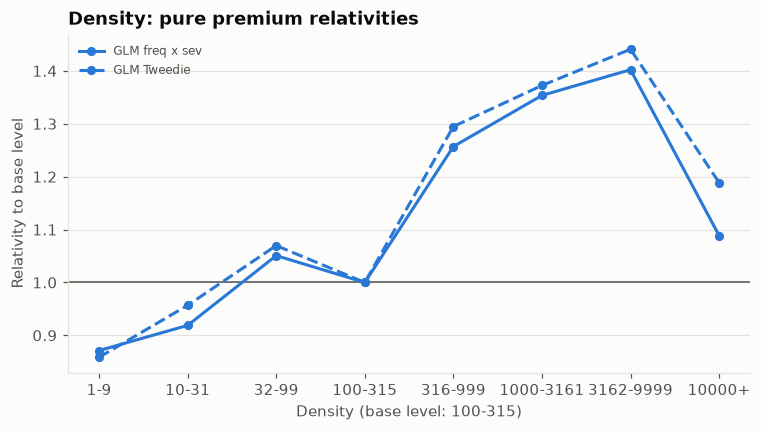

In [8]:
tweedie_rel = relativities(tweedie_glm, levels, base)
with open(PROCESSED / "frequency_glm.pkl", "rb") as fh:
    freq_saved = pickle.load(fh)
freq_params, sev_params = freq_saved["results"].params, sev_saved["results"].params

for factor in ["DrivAge", "BonusMalus", "Density"]:
    lvls = band_labels(BANDS[factor])
    combined = [
        float(np.exp(freq_params.get(f"{factor}[{lvl}]", 0.0) + sev_params.get(f"{factor}[{lvl}]", 0.0)))
        for lvl in lvls
    ]
    tw = tweedie_rel.filter(pl.col("factor") == factor)
    tw_values = [tw.filter(pl.col("level") == lvl)["relativity"][0] for lvl in lvls]
    fig = plot_relativity_comparison(
        {"GLM freq x sev": combined, "GLM Tweedie": tw_values}, lvls, factor, base[factor]
    )
    save(fig, f"pp_relativities_{factor.lower()}")
    plt.show()

The two GLMs agree on the shape of each factor but not on its size at the extremes. The Tweedie GLM puts young drivers 10 to 20% lower and the worst BonusMalus bands about 20% higher than frequency x severity does.

The reason is in what each approach assumes. Frequency x severity estimates the two parts separately, so a factor can affect how often a policy claims without affecting what each claim costs, and the severity model here uses only three factors. A single Tweedie model estimates one combined effect per factor and weights the data by a variance that grows with the mean to the power 1.8, which is not the same as fitting frequency and severity each on their own terms. Neither set of relativities is "the right one"; the test set below shows which predicts better.

## 4. Tweedie GBM

Tuned with 5-fold cross-validation on the training data at the chosen power, then fitted on all of it and rebased.

In [9]:
G_train = gbm_matrix(train)
grid = [{"num_leaves": nl, "min_data_in_leaf": md} for nl in (15, 31, 63) for md in (200, 2000)]
cv_rows = []
for params in grid:
    rounds, score = cv_tweedie_gbm(G_train, cost_train, e_train, POWER, params)
    cv_rows.append({**params, "trees": rounds, "cv_tweedie_nll": score})
cv_results = pl.DataFrame(cv_rows).sort("cv_tweedie_nll")
cv_results

num_leaves,min_data_in_leaf,trees,cv_tweedie_nll
i64,i64,i64,f64
15,200,78,15.9901
15,2000,71,15.9905
31,2000,51,16.0041
31,200,51,16.0057
63,2000,41,16.0185
63,200,29,16.0232


In [10]:
best = cv_results.row(0, named=True)
tweedie_gbm = TweedieGBM(POWER, {"num_leaves": best["num_leaves"], "min_data_in_leaf": best["min_data_in_leaf"]}, best["trees"])
tweedie_gbm.fit(G_train, cost_train, e_train)
print(f"Rebasing factor: {tweedie_gbm.rebase:.3f}")

Rebasing factor: 1.104


## 5. Test set: four models compared

All four models are scored once on the test set, against capped claim cost:

- **Tweedie deviance** at the chosen power: the pricing team's accuracy measure for pure premium. Lower is better.
- **Gini**: how well each model ranks policies by cost.
- **Balance**: total predicted cost over total observed capped cost.

In [11]:
test_b = add_glm_bands(test)
pred_test["GLM Tweedie"] = predict(tweedie_glm, glm_design_matrix(test_b, levels, base))
pred_test["GBM Tweedie"] = tweedie_gbm.predict(gbm_matrix(test))

scores = pl.DataFrame([
    {"model": m, f"tweedie_deviance_p{POWER}": tweedie_deviance(cost_test, p, e_test, POWER),
     "gini": gini(cost_test, p, e_test), "balance": balance(cost_test, p, e_test)}
    for m, p in pred_test.items()
])
scores

model,tweedie_deviance_p1.8,gini,balance
str,f64,f64,f64
"""GLM freq x sev""",29.9225,0.3112,0.9449
"""GBM freq x sev""",29.6123,0.3537,0.9240
"""GLM Tweedie""",29.9264,0.3169,0.9637
"""GBM Tweedie""",29.7815,0.3300,0.9455


**All four models under-predict the test set by 4 to 8%.** As in the earlier notebooks this is mostly the split: the test set's capped cost per policy-year is about 6% higher than the training set's (EUR 135.5 against EUR 127.9), from slightly more claims and slightly more expensive ones. It affects all four models alike, so it does not change how they compare.

**The GBM frequency x severity model is best on both deviance and Gini.** The Tweedie GBM comes second, and the two GLMs are close to each other: frequency x severity has marginally lower deviance, Tweedie a marginally higher Gini.

The likely reason the GBM does better as frequency x severity than as one Tweedie model is the earlier finding that severity carries almost no signal. Split into two models, the frequency GBM learns from claim counts alone, and the weak severity model adds little noise. A single Tweedie GBM has to learn from claim amounts that mix the useful frequency signal with a lot of cost noise, and early stopping ended it after 78 small trees. This is an interpretation of the results, not something tested directly here.

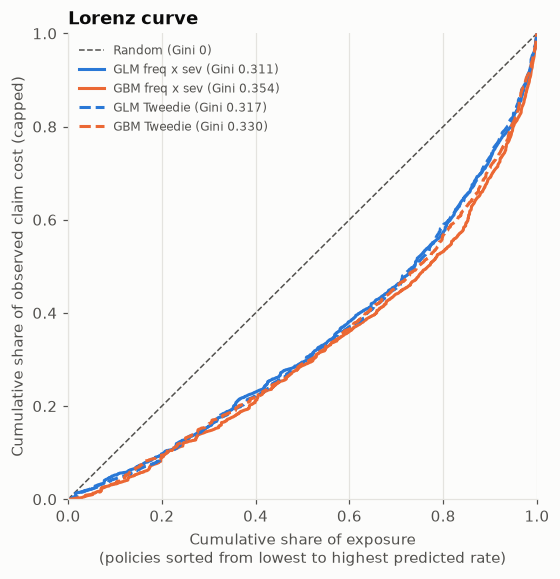

In [12]:
fig = plot_lorenz(
    {m: lorenz_curve(cost_test, p, e_test) for m, p in pred_test.items()},
    {m: gini(cost_test, p, e_test) for m, p in pred_test.items()},
    ylabel="Cumulative share of observed claim cost (capped)",
)
save(fig, "pp_lorenz_test")
plt.show()

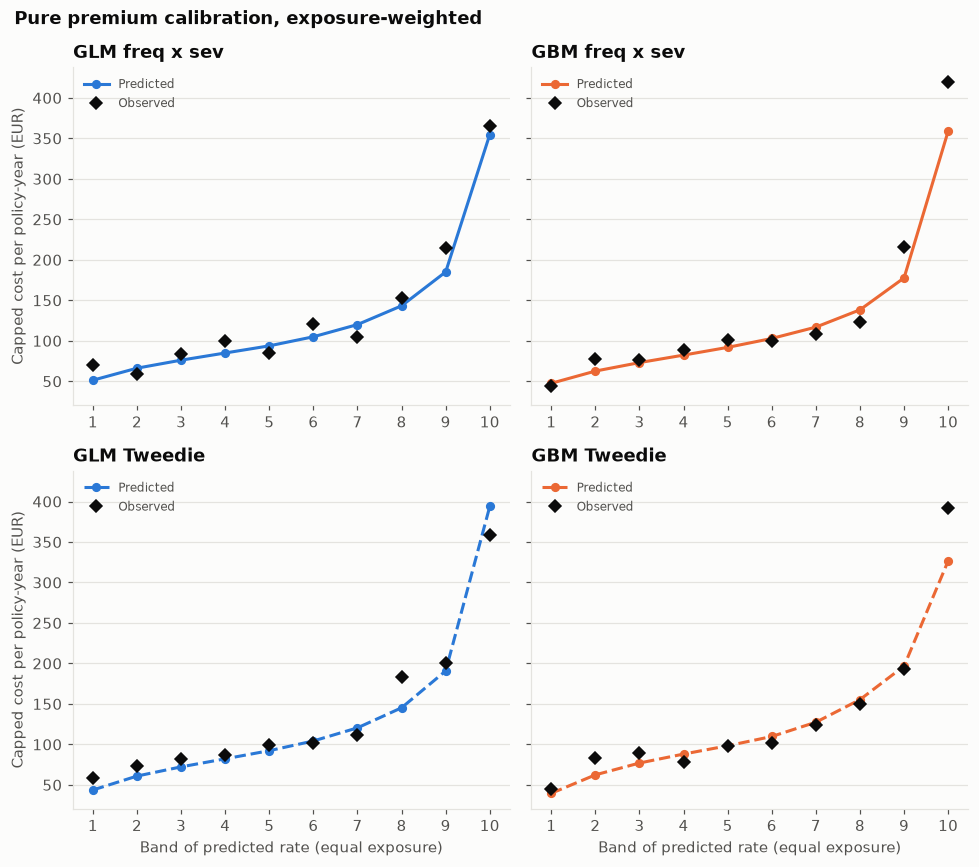

In [13]:
calib = {m: calibration_table(cost_test, p, e_test) for m, p in pred_test.items()}
fig = plot_calibration(calib, ylabel="Capped cost per policy-year (EUR)", title="Pure premium calibration, exposure-weighted")
save(fig, "pp_calibration_test")
plt.show()

The calibration charts show where the models differ. In the top band, the policies each model predicts as most expensive, the GBMs gather more of the observed cost (about EUR 390 to 420 per policy-year, against about EUR 360 for the GLMs), which is what a higher Gini means in practice. All four under-predict that top band, the GBMs most, so the most expensive policies are where calibration is weakest.

## 6. Adding the large-loss loading back

The models above predict capped cost. The premium also has to cover the cost above the cap, so each prediction is multiplied by $(1 + \text{loading})$, the loading estimated on the training data in the severity notebook. The balance below compares that against the test set's full cost, including its own large losses.

In [14]:
loading = sev_saved["large_loss_loading"]
total_test = cost_test.sum() + test["ClaimAmountExcess"].sum()
print(f"Large-loss loading from training: {loading:.1%}")
print(f"Test cost above the cap: EUR {test['ClaimAmountExcess'].sum():,.0f} "
      f"({test['ClaimAmountExcess'].sum() / cost_test.sum():.1%} of test capped cost)")
pl.DataFrame([
    {"model": m, "balance vs total cost incl. large losses": float(np.sum(p * (1 + loading) * e_test) / total_test)}
    for m, p in pred_test.items()
])

Large-loss loading from training: 30.9%
Test cost above the cap: EUR 2,164,521 (22.3% of test capped cost)


model,balance vs total cost incl. large losses
str,f64
"""GLM freq x sev""",1.0116
"""GBM freq x sev""",0.9892
"""GLM Tweedie""",1.0318
"""GBM Tweedie""",1.0122


With the loading added, all four models come within about 3% of the test set's total cost. That is partly luck: the test set's large losses came to 22% of its capped cost, against the 31% loading estimated on training, and that happens to offset the test set's higher capped cost. With a different split the two could just as easily have pushed in the same direction. It is another reminder that a loading estimated from one sample of large losses is uncertain.

## 7. Save predictions

Test-set pure premiums from all four models are saved for the evaluation and commercial analysis notebooks.

In [15]:
test.select("IDpol", "Exposure", "ClaimNb", "ClaimAmount", "ClaimAmountExcess").with_columns(
    pl.Series("pp_glm_fs", pred_test["GLM freq x sev"]),
    pl.Series("pp_gbm_fs", pred_test["GBM freq x sev"]),
    pl.Series("pp_glm_tweedie", pred_test["GLM Tweedie"]),
    pl.Series("pp_gbm_tweedie", pred_test["GBM Tweedie"]),
).write_parquet(PROCESSED / "pure_premium_test_predictions.parquet")

tweedie_glm.remove_data()
with open(PROCESSED / "tweedie_glm.pkl", "wb") as fh:
    pickle.dump({"results": tweedie_glm, "levels": levels, "base": base, "power": POWER}, fh)
tweedie_gbm.booster.save_model(PROCESSED / "tweedie_gbm.txt")